In [1]:
%matplotlib inline
from IPython.display import display, clear_output

import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import numpy as np
import time

from functools import partial
from tqdm.notebook import tqdm
from typing import NamedTuple

In [2]:
alphabets = [0, 1, 2, 3] # {0, 1, +, \eps}
motions = [0, 1, 2, 3, 4] # {U, D, L, R, S}
output_alphabets = [0, 1, 3] # {0, 1, \eps}

In [3]:
seed = 42
hidden_dim = 12
max_input_length = 1
grid_size = (2, 4)

In [4]:
rng = jrandom.PRNGKey(seed)

# TODO: Multitape instead of grid
hidden_map = jrandom.normal(rng, shape=(
    len(alphabets), hidden_dim, hidden_dim,
))
hidden_map = hidden_map / jnp.linalg.norm(hidden_map, axis=-1, keepdims=True)

symbol_map = jrandom.normal(rng, shape=(
    len(alphabets), len(alphabets), hidden_dim, 
))
symbol_map = symbol_map / jnp.linalg.norm(symbol_map, axis=-1, keepdims=True)

motion_map = jrandom.normal(rng, shape=(
    len(alphabets), len(motions), hidden_dim,
))
motion_map = motion_map / jnp.linalg.norm(motion_map, axis=-1, keepdims=True)

In [5]:
N = 25
max_episodes = 100
max_steps = 5
lr = 1e-3
lr_hidden = 1e-3
gamma = 1.0

In [6]:
def binary_to_decimal(input):
    return jnp.sum(input * 2 ** jnp.arange(len(input))[::-1])

def decimal_to_binary(input):
    return [int(x) for x in list('{0:0b}'.format(input))]

class StepState(NamedTuple):
    hidden_params: jax.Array
    past_read_symbols: jax.Array
    curr_hidden_state: jax.Array

def rollout(timestep_i, state):
    return StepState(
        state.hidden_params,
        state.past_read_symbols,
        state.hidden_params[state.past_read_symbols[timestep_i]] @ state.curr_hidden_state,
    )

def compute_pg(params, past_read_symbols, init_hidden_state, write_symbol, move_symbol, curr_ret):

    hidden_state = jax.lax.fori_loop(
        0,
        len(past_read_symbols),
        rollout,
        StepState(
            hidden_params=params["hidden"],
            past_read_symbols=past_read_symbols,
            curr_hidden_state=init_hidden_state,
        ),
    )
    hidden_state = hidden_state.curr_hidden_state

    write_logits = params["write"] @ hidden_state
    move_logits = params["move"] @ hidden_state

    write_lprobs = jnp.sum(
        write_logits, axis=-1, where=write_symbol,
    ) - jax.nn.logsumexp(write_logits, axis=-1)

    move_lprobs = jnp.sum(
        move_logits, axis=-1, where=move_symbol,
    ) - jax.nn.logsumexp(move_logits, axis=-1)

    loss = -(move_lprobs + write_lprobs) * curr_ret
    return loss, {
        "write_lprobs": write_lprobs,
        "move_lprobs": move_lprobs,
    }

def compute_pg_first_step(params, init_hidden_state, write_symbol, move_symbol, curr_ret):
    write_logits = params["write"] @ init_hidden_state
    move_logits = params["move"] @ init_hidden_state

    write_lprobs = jnp.sum(
        write_logits, axis=-1, where=write_symbol,
    ) - jax.nn.logsumexp(write_logits, axis=-1)

    move_lprobs = jnp.sum(
        move_logits, axis=-1, where=move_symbol,
    ) - jax.nn.logsumexp(move_logits, axis=-1)

    loss = -(move_lprobs + write_lprobs) * curr_ret
    return loss


def smooth_rewards(iterations, ep_rew, N):
    """
    Smooth episodic rewards using a moving average over N episodes.
    
    Parameters:
    -----------
    iterations : list
        List of iteration numbers [0, 1, 2, ...]
    ep_rew : list
        List of episodic rewards corresponding to each iteration
    N : int
        Window size for smoothing (number of episodes)
    
    Returns:
    --------
    smoothed_iterations : numpy.ndarray
        Iterations corresponding to smoothed rewards
    smoothed_rewards : numpy.ndarray
        Smoothed episodic rewards
    """
    ep_rew = np.array(ep_rew)
    iterations = np.array(iterations)
    
    # Calculate moving average using convolution
    smoothed = np.convolve(ep_rew, np.ones(N)/N, mode='valid')
    
    # Adjust iterations to match smoothed rewards length
    # The smoothed array is shorter by N-1 elements
    smoothed_iter = iterations[N-1:]
    
    return smoothed_iter, smoothed

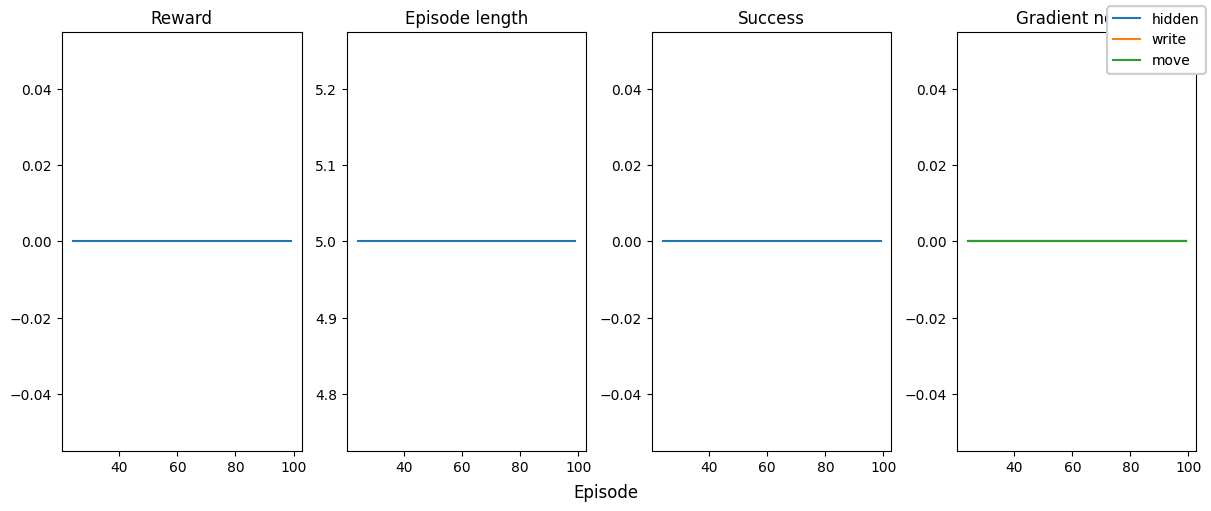

In [7]:
iterations = []
ep_rew = []
ep_len = []
all_trajs = []
all_grad_norms = {
    "hidden": [],
    "write": [],
    "move": [],
}

fig, axes = plt.subplots(1, 4, figsize=(12, 5), layout="constrained")
fig.supxlabel("Episode")

for ep_i in tqdm(range(max_episodes)):
    rng = jrandom.fold_in(rng, ep_i)
    input_length = jrandom.choice(rng, max_input_length) + 1
    inputs = jrandom.bernoulli(rng, shape=(2, input_length))
    question = jnp.concatenate((inputs[0], jnp.array([2]), inputs[1]))

    input_1_dec = binary_to_decimal(inputs[0])
    input_2_dec = binary_to_decimal(inputs[2])
    answer_dec = input_1_dec + input_2_dec
    answer = decimal_to_binary(answer_dec)
    answer_str = "".join([str(el) for el in answer])

    curr_pointer = jnp.zeros(2, dtype=int)
    curr_state = jnp.full(grid_size, fill_value=alphabets[-1])
    curr_state = curr_state.at[0, :len(question)].set(question)

    traj = []
    hidden_state = jnp.eye(hidden_dim)[0]
    # jnp.ones(hidden_dim) / np.sqrt(hidden_dim)
    reward = 0.0
    for timestep_i in range(max_steps * input_length):
        rng = jrandom.fold_in(rng, timestep_i)
        write_rng, move_rng = jrandom.split(rng)
        curr_symbol = curr_state[curr_pointer[0], curr_pointer[1]]

        next_hidden_state = hidden_map[curr_symbol] @ hidden_state
        write_symbol = jrandom.categorical(
            write_rng,
            logits=symbol_map[curr_symbol] @ next_hidden_state,
        )
        move_symbol = jrandom.categorical(
            move_rng,
            logits=motion_map[curr_symbol] @ next_hidden_state,
        )

        traj.append((
            curr_state,
            curr_pointer,
            write_symbol,
            move_symbol,
            hidden_state,
            curr_symbol,
        ))

        hidden_state = next_hidden_state
        curr_state = curr_state.at[curr_pointer[0], curr_pointer[1]].set(write_symbol)

        axis = int(move_symbol >= 2)
        if move_symbol != 4:
            curr_pointer = curr_pointer.at[axis].set(jnp.clip(
                curr_pointer[axis] + (-1) ** (move_symbol % 2),
                a_min=0,
                a_max=grid_size[axis] - 1,
            ).astype(int))

        all_empty = True
        see_correct = False
        for row in curr_state:
            if not see_correct and answer_str == "".join([str(el) if el < alphabets[-1] else "" for el in row]):
                see_correct = True
            else:
                all_empty = False
                break

        reward = int(see_correct and all_empty)

        if reward == 1:
            break

    traj.append((
        curr_state,
        curr_pointer,
        None,
        None,
        hidden_state,
        curr_symbol,
    ))

    iterations.append(ep_i)
    ep_rew.append(reward)
    ep_len.append(len(traj) - 1)

    if ep_i >= max_episodes - 100:
        all_trajs.append(traj)

    returns = reward * (gamma ** np.arange(len(traj) - 1)[::-1])

    init_hidden_state = traj[0][4]
    grad_norms = {
        "hidden": [],
        "write": [],
        "move": [],
    }
    for timestep_i in np.arange(len(returns)):
        curr_ret = returns[timestep_i]

        curr_transition = traj[timestep_i]
        read_symbol = curr_transition[0][curr_transition[1][0], curr_transition[1][1]]
        write_symbol, move_symbol = curr_transition[2], curr_transition[3]

        past_read_symbols = jnp.array([
            transition_i[5]
            for transition_i in traj[:timestep_i + 1]
        ], dtype=int)

        (loss, aux), grads = jax.value_and_grad(compute_pg, has_aux=True)(
            {
                "hidden": hidden_map,
                "write": symbol_map[read_symbol],
                "move": motion_map[read_symbol],
            },
            past_read_symbols,
            init_hidden_state,
            write_symbol,
            move_symbol,
            curr_ret,
        )

        hidden_map = hidden_map - lr_hidden * grads["hidden"]
        symbol_map = symbol_map.at[read_symbol].set(symbol_map[read_symbol] - lr * grads["write"])
        motion_map = motion_map.at[read_symbol].set(motion_map[read_symbol] - lr * grads["move"])
        grad_norms["hidden"].append(jnp.linalg.norm(grads["hidden"]))
        grad_norms["write"].append(jnp.linalg.norm(grads["write"]))
        grad_norms["move"].append(jnp.linalg.norm(grads["move"]))

    all_grad_norms["hidden"].append(np.mean(grad_norms["hidden"]))
    all_grad_norms["write"].append(np.mean(grad_norms["write"]))
    all_grad_norms["move"].append(np.mean(grad_norms["move"]))

    for ax in axes:
        ax.clear()
    axes[0].set_title("Reward")
    axes[1].set_title("Episode length")
    axes[2].set_title("Success")
    axes[3].set_title("Gradient norm")

    ep_success = (np.array(ep_rew) > 0.0).astype(int)
    curr_N = min(len(ep_rew), N)
    smoothed_it, smoothed_ep_rew = smooth_rewards(iterations, ep_rew, curr_N)
    _, smoothed_ep_len = smooth_rewards(iterations, ep_len, curr_N)
    _, smoothed_ep_success = smooth_rewards(iterations, ep_success, curr_N)
    axes[0].plot(smoothed_it, smoothed_ep_rew)
    axes[1].plot(smoothed_it, smoothed_ep_len)
    axes[2].plot(smoothed_it, smoothed_ep_success)

    for key, grad_norm in all_grad_norms.items():
        _, smoothed_grad_norm = smooth_rewards(iterations, grad_norm, curr_N)
        axes[3].plot(smoothed_it, smoothed_grad_norm, label=key)
    fig.legend()

    display(fig)
    clear_output(wait=True)
    plt.pause(0.01)


In [8]:
np.sum(ep_rew)

np.int64(0)

In [9]:
for traj, curr_rew in zip(all_trajs[-100:], ep_rew[-100:]):
    if curr_rew <= 0:
        continue
    for sample in traj:
        state = np.array(sample[0])
        str_state = [
            [f" {el}" for el in row] for row in state
        ]
        str_state[sample[1][0]][sample[1][1]] = f".{state[sample[1][0], sample[1][1]]}"
        clear_output(wait=True)
        display(np.array(str_state))
        time.sleep(0.5)